# 读取数据

In [1]:
import  pandas as pd
REE_COLS = ['Ce', 'Dy', 'Er', 'Eu', 'Gd', 'Ho', 'Lu', 'Nd', 'Sm', 'Th', 'Tm', 'U', 'Yb']
# 1. 读取数据
file_path = r'G:\PythonProject\Bishe\data\raw\BiShe-total_data.CSV'
df = pd.read_csv(file_path)
df

,lat,lon,class,Ce,Dy,Er,Eu,Gd,Ho,Lu,Nd,Sm,Th,Tm,U,Yb
0,40.49,-121.51,magmatic,8.45,31.79,58.36,0.49,5.73,12.14,28.29,0.30,0.85,32.0,14.37,65.0,139.69
1,40.49,-121.51,magmatic,46.28,66.46,189.80,0.51,14.86,37.68,88.34,0.57,1.69,314.0,46.54,511.0,436.00
2,40.49,-121.51,magmatic,68.14,90.61,225.64,0.85,21.73,45.38,96.36,0.72,2.46,757.0,53.23,811.0,501.76
3,40.49,-121.51,magmatic,170.38,303.39,519.85,2.95,70.00,111.31,217.11,2.78,7.38,3497.0,119.34,2127.0,1104.03
4,40.49,-121.51,magmatic,18.54,41.55,87.39,0.27,7.40,16.25,42.14,0.14,0.81,67.0,21.60,137.0,199.80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7213,-25.17,-50.08,hydrothermal,1046.00,183.00,117.00,9.00,147.00,35.00,24.00,1046.00,242.00,6098.0,20.00,2046.0,162.00
7214,-25.17,-50.08,hydrothermal,1461.00,341.00,230.00,15.00,252.00,69.00,41.00,1257.00,339.00,7620.0,39.00,2035.0,298.00
7215,-25.17,-50.08,hydrothermal,1267.00,284.00,183.00,9.00,214.00,56.00,29.00,1274.00,291.00,3615.0,30.00,1386.0,217.00
7216,-25.17,-50.08,hydrothermal,1196.00,298.00,209.00,10.00,205.00,64.00,36.00,1384.00,343.00,3559.0,35.00,950.0,267.00


In [2]:
df['class'].value_counts()

class
detrital        3437
magmatic        2517
hydrothermal     536
metamorphic      400
Name: count, dtype: int64

In [3]:
# 移除缺失标签的样本
df_labeled = df.dropna(subset=['class']).copy()
# 处理特征缺失值 - 使用中位数填充
for col in REE_COLS:
    df_labeled[col] = df_labeled[col].fillna(df_labeled[col].median())

# 划分数据集

In [4]:
from sklearn.model_selection import train_test_split

# 划分特征和标签
X = df_labeled.drop(['lat','lon','class'], axis=1)  # 特征
y = df_labeled['class'] # 标签
# 将数据集按7:3划分为训练数据、验证数据、测试数据
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42,stratify=y)
x_valid,x_test,y_valid,y_test = train_test_split(x_test,
                                                   y_test,
                                                   test_size=0.5,
                                                   random_state=42,
                                                   stratify=y_test)

In [5]:
# 标签编码
from sklearn.preprocessing import LabelEncoder

# 1. 初始化编码器
le = LabelEncoder()

# 2. 只用训练集拟合
y_train_encoded = pd.DataFrame(le.fit_transform(y_train),index=None,columns=['label'])
y_valid_encoded = pd.DataFrame(le.transform(y_valid),index=None,columns=['label'])

# 3. 测试集只做transform（不能再fit）
y_test_encoded = pd.DataFrame(le.transform(y_test),index=None,columns=['label'])

# 查看类别对应关系
print("类别映射关系：")
for i, class_name in enumerate(le.classes_):
    print(f"{class_name} -> {i}")

类别映射关系：
detrital -> 0
hydrothermal -> 1
magmatic -> 2
metamorphic -> 3


# 原始数据划分后保存

In [42]:
# 保存数据集
x_train.to_csv( 'G:/PythonProject/Bishe/data/raw/x_train_raw.csv')
x_valid.to_csv( 'G:/PythonProject/Bishe/data/raw/x_valid_raw.csv')
x_test.to_csv( 'G:/PythonProject/Bishe/data/raw/x_test_raw.csv')
y_train_encoded.to_csv('G:/PythonProject/Bishe/data/raw/y_train_raw.csv')
y_valid_encoded.to_csv('G:/PythonProject/Bishe/data/raw/y_valid_raw.csv')
y_test_encoded.to_csv('G:/PythonProject/Bishe/data/raw/y_test_raw.csv')

In [43]:
y_train_encoded.shape

(4823, 1)

In [44]:
x_train

,Ce,Dy,Er,Eu,Gd,Ho,Lu,Nd,Sm,Th,Tm,U,Yb
4461,7.20,76.58,145.64,0.63,17.58,30.62,69.77,1.03,2.70,87.93,32.49,214.05,320.83
1717,29.90,53.80,92.50,0.51,13.40,19.40,34.10,1.25,2.44,101.00,19.40,64.00,208.00
5994,15.00,131.00,187.00,2.20,41.00,43.00,60.00,6.00,9.20,163.00,35.00,177.00,348.00
7077,33.00,112.00,135.00,0.90,46.00,36.00,39.00,44.00,28.00,400.00,26.00,903.00,212.00
1553,11.60,68.70,119.20,0.28,14.30,23.90,41.70,1.66,3.30,80.00,23.20,80.00,253.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3993,8.95,62.50,135.00,0.27,11.20,24.80,67.20,0.63,1.29,185.00,32.90,536.00,322.00
5601,13.70,330.00,518.00,0.36,79.20,115.00,152.00,7.10,16.00,1010.00,98.00,2013.00,987.00
6638,11.80,68.50,108.00,0.13,15.60,25.20,35.10,0.64,2.45,190.00,22.10,386.00,195.00
6847,53.80,109.25,195.96,1.99,29.99,41.19,88.14,3.13,6.06,282.32,46.80,282.54,411.76


In [45]:
x_valid

,Ce,Dy,Er,Eu,Gd,Ho,Lu,Nd,Sm,Th,Tm,U,Yb
1154,6.69,129.35,228.76,0.49,27.55,50.37,94.71,1.94,3.98,89.09,49.80,110.18,474.70
2401,1.29,45.90,33.40,0.62,14.00,9.91,6.31,1.56,1.36,28.60,5.08,2889.00,42.10
107,11.10,148.00,281.00,1.01,32.20,60.60,111.00,2.49,4.78,246.00,56.70,318.00,536.00
4572,3.23,85.25,171.36,0.17,14.35,35.08,75.84,0.65,1.99,80.82,38.05,342.63,360.62
2126,11.40,54.30,105.20,0.18,10.30,20.70,41.60,0.53,1.38,155.00,21.90,249.00,231.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1050,69.64,195.70,265.34,234.04,59.19,43.64,48.74,85.23,51.46,358.89,33.69,508.59,603.93
6120,23.61,82.00,143.00,1.54,24.45,32.00,68.00,7.06,5.40,323.00,33.00,475.00,316.00
4799,3.84,123.20,188.30,0.59,27.90,42.60,55.20,1.74,4.52,14.88,39.50,61.12,369.00
1376,23.10,55.50,124.00,1.18,11.50,22.80,74.10,1.06,1.93,126.00,29.10,223.00,427.00


In [46]:
x_test

,Ce,Dy,Er,Eu,Gd,Ho,Lu,Nd,Sm,Th,Tm,U,Yb
1059,180.44,52.53,87.23,106.66,25.06,25.37,41.27,130.05,41.07,99.68,26.78,90.99,210.42
4065,11.94,85.70,160.00,0.73,16.70,35.40,84.30,1.57,2.90,322.00,36.40,614.00,372.00
5506,16.12,16.23,65.10,0.21,2.01,38.78,71.76,0.63,0.50,312.48,44.80,993.45,60.30
120,56.80,105.00,184.00,3.04,29.00,38.70,89.70,28.00,11.60,266.00,42.00,534.00,433.00
2231,11.20,64.00,133.10,0.31,12.40,24.90,57.30,0.68,1.90,124.00,30.50,233.00,380.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1494,17.90,122.60,185.00,1.53,34.80,41.00,61.50,4.48,7.48,163.00,37.30,130.00,379.00
1491,6.70,38.00,69.50,0.82,9.00,14.20,28.40,1.09,1.75,188.00,15.30,126.00,170.00
6582,11.40,28.30,53.50,0.99,8.40,10.90,32.90,1.07,1.60,108.00,12.30,374.00,138.00
6191,40.19,554.00,951.00,0.11,115.50,210.00,335.00,4.06,14.56,3714.00,196.00,8106.00,1706.00


# 数据探索

## 计算数据的方差(蕴含信息)

In [6]:
# 1. 拿到列名
columns = x_train.columns
df[columns].var()

Ce    1.704874e+04
Dy    3.071322e+04
Er    5.776268e+04
Eu    1.319025e+04
Gd    3.586195e+03
Ho    3.024306e+03
Lu    3.683879e+04
Nd    6.294036e+03
Sm    1.392785e+03
Th    1.075471e+06
Tm    2.755081e+03
U     3.466631e+06
Yb    2.925718e+05
dtype: float64

## 相关性热图

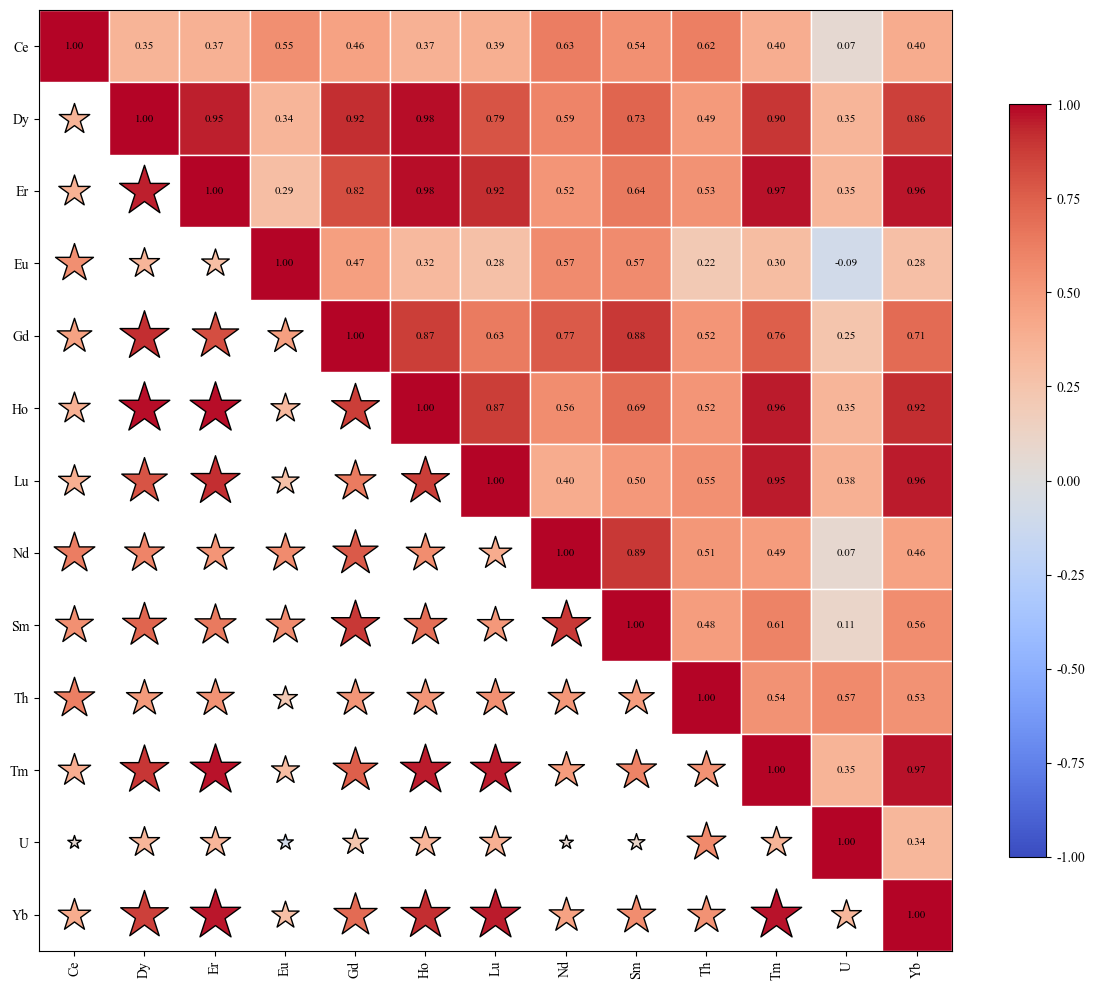

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# ========== 基础设置 ==========
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams['axes.unicode_minus'] = False

# 计算斯皮尔曼相关系数矩阵
matrix = x_train.corr(method='spearman')
labels = matrix.columns
n = len(labels)

fig, ax = plt.subplots(figsize=(12,10))

# 设置坐标范围
ax.set_xlim(0, n)
ax.set_ylim(0, n)
# 关闭坐标轴网格
ax.grid(False)

# 颜色映射
cmap = plt.cm.coolwarm
norm = plt.Normalize(-1, 1)

for i in range(n):
    for j in range(n):
        value = matrix.iloc[i, j]

        # -------- 上三角（数值）--------
        if i <= j:
            ax.add_patch(plt.Rectangle((j, n-i-1), 1, 1,
                                       facecolor=cmap(norm(value)),
                                       edgecolor='white'))
            ax.text(j+0.5, n-i-1+0.5,
                    f"{value:.2f}",
                    ha='center', va='center',
                    fontsize=8)

        # -------- 下三角（五角星）--------
        else:
            size = abs(value) * 1500   # 控制星星大小

            ax.scatter(j+0.5, n-i-1+0.5,
                       s=size,
                       c=[cmap(norm(value))],
                       marker='*',
                       edgecolors='black')

# 设置坐标轴
ax.set_xticks(np.arange(n)+0.5)
ax.set_yticks(np.arange(n)+0.5)
ax.set_xticklabels(labels, rotation=90)
ax.set_yticklabels(labels[::-1])
# ax.set_title("Spearman Correlation Matrix", fontsize=14)

# 添加颜色条
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=ax, shrink=0.8)
plt.tight_layout()
plt.savefig('Feature Correlation Matrix',dpi=600,bbox_inches='tight')
plt.show()